# Welltory COVID-19 Data Exploration

**Course:** AIPI 510 (Fall 2025)  
**Author:** Eugenia Tate  
**Date:** September 15, 2025  

This notebook reads the `participants.csv` file from the Welltory COVID-19 dataset and explores its data in order to answer the following questions:

1. Understand your data - what do the features mean?  
2. Document data context and data sampling in markdown  
3. Explore and interpret data structure, descriptive statistics, data quality, and variable relationships  
4. Explore data visually with appropriate visualizations  
5. Discuss and implement strategies for handling missing values, duplicates, and outliers  
6. Perform data transformation as appropriate  
7. Create at least one new feature and document the approach  
8. Include a discussion around data quality (profiling, completeness, accuracy, consistency, integrity, provenance)  
9. Provide rationale for all choices  


## 1. Data Context

**Question:**  
*Document data context and data sampling in markdown.*


**Answer:** 
This file comes from the Welltory app during the COVID-19 pandemic.  
People shared info about themselves (like gender, age group, height, weight) and sometimes reported when they got symptoms.  

Things to keep in mind:  
- Not everyone filled everything in.  
- Numbers may not be accurate since people typed them themselves.  
- Users of this app are not the whole population, so it’s a biased sample.  

## 2. What Do the Columns Mean

**Question:**  
*Understand your data - what do the features mean?*

**Answer:**  
- **user_code**: random ID for each person  
- **gender**: "m" or "f" (sometimes missing)  
- **age_range**: group like 18–24, 25–34, etc.  
- **city**: city name (often blank)  
- **country**: country name (sometimes missing)  
- **height**: height in cm  
- **weight**: weight in kg  
- **symptoms_onset**: date when person said they got COVID symptoms (if reported)  

In [ ]:
# Step 3: Import libraries and read the participants.csv file

import pandas as pd               # for data tables
import numpy as np                # for numerical calculations
import matplotlib.pyplot as plt   # for plotting
import seaborn as sns             # for nicer plots

# make pandas show all columns when printing a dataframe
pd.set_option("display.max_columns", None)

# set seaborn's default style for charts
sns.set(style="whitegrid")

# read the CSV file into a pandas DataFrame
df = pd.read_csv("../data/week4/participants.csv")

# look at the first 5 rows 
df.head(5)

,user_code,gender,age_range,city,country,height,weight,symptoms_onset
0,007b8190cf,m,25-34,Mandalay,Myanmar,170.18,96.162,NaN
1,013f6d3e5b,f,18-24,São Paulo,Brazil,174.00,77.300,5/15/2020
2,01bad5a519,m,45-54,St Petersburg,Russia,178.00,92.000,4/5/2020
3,0210b20eea,f,25-34,Sochi,Russia,169.00,60.000,5/6/2020
4,024719e7da,f,45-54,St Petersburg,Russia,158.00,68.500,5/27/2020


## 4. Data Structure & Descriptive Statistics

**Question:**  
*Explore and interpret data structure and descriptive statistics.*

**Answer:**  
Before doing any data cleaning or analysis, it’s important to understand the basic structure of the dataset.  

Here we check:
- **Shape**: how many rows (participants) and columns (features) the file has  
- **Column types**: types of the columns (numbers, text, dates)
- **Descriptive statistics**: quick stats like min, max, average 

This step helps us spot any data that is weird or out of place:
- Columns that are not stored in the right type (e.g., numbers read as text)  
- Obvious outliers 

In [6]:
# Step 4: Data Structure & Descriptive Statistics

# number of rows and columns
print("Dataset shape (rows, columns):", df.shape)

# column types and non-null counts
print("\nColumn info:")
print(df.info())

# summary statistics for both numbers and categories
print("\nSummary statistics:")
df.describe(include="all").T

Dataset shape (rows, columns): (185, 8)

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_code       185 non-null    object 
 1   gender          185 non-null    object 
 2   age_range       185 non-null    object 
 3   city            173 non-null    object 
 4   country         179 non-null    object 
 5   height          183 non-null    float64
 6   weight          185 non-null    float64
 7   symptoms_onset  147 non-null    object 
dtypes: float64(2), object(6)
memory usage: 11.7+ KB
None

Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_code,185,185,007b8190cf,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,185,2,f,118,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_range,185,6,35-44,56,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,173,116,Moscow,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,179,25,Russia,66,NaN,NaN,NaN,NaN,NaN,NaN,NaN
height,183.0,NaN,NaN,NaN,169.976393,12.400103,132.08,163.5,168.0,174.5,250.0
weight,185.0,NaN,NaN,NaN,77.927757,19.552541,43.5,63.5,74.344,90.537,154.221
symptoms_onset,147,74,5/6/2020,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Data Quality Check

**Question:**  
*Explore and interpret data quality. Discuss missing values, duplicates, and outliers.*

**Answer:**  
In this step, we check for the following:  
- Missing values (which columns have blanks)  
- Duplicates (same person more than once)  
- Outliers (like someone 250 cm tall or weighs 5 kg)  

This helps us decide what kind of cleaning is needed.

Missing values (fraction of rows missing per column):
symptoms_onset    0.205405
city              0.064865
country           0.032432
height            0.010811
user_code         0.000000
gender            0.000000
age_range         0.000000
weight            0.000000
dtype: float64

Number of duplicate rows: 0


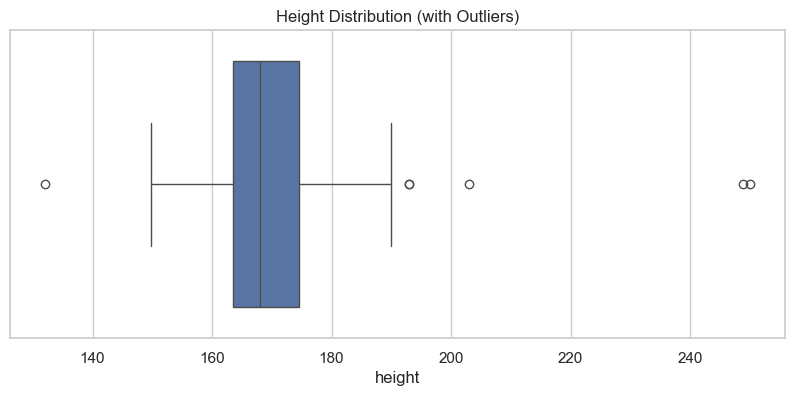

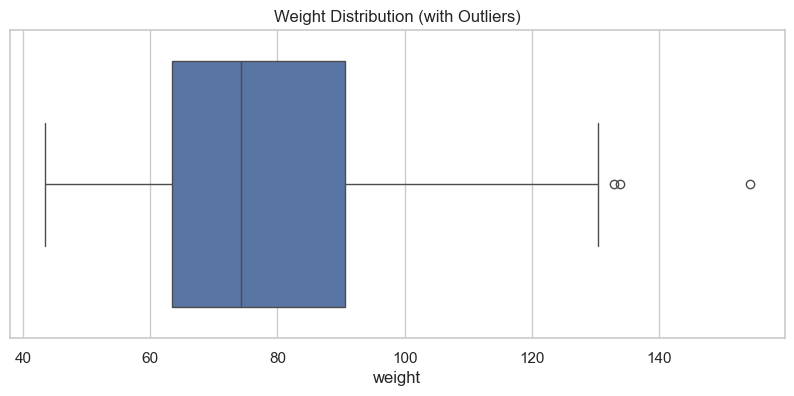

In [ ]:
# Step 5: Data Quality Check

# missing values
print("Missing values (fraction of rows missing per column):")
print(df.isnull().mean().sort_values(ascending=False))

# duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

# outlier check with boxplots for height and weight
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['height'])
plt.title("Height Distribution (with Outliers)")
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(x=df['weight'])
plt.title("Weight Distribution (with Outliers)")
plt.show()

## 6. Visual Exploration

**Question:**  
*Explore data visually with appropriate visualizations.*

**Answer:** 
Charts and plots help us understand the data better than numbers alone.  
Here we will look at:  
- **Distributions of numeric features** like height and weight via histograms
- **Distributions of categorical features** like gender and age range via bar charts
- **Country distribution** (top 10 countries with the most participants) via bar chart
- **Relationships between variables**, such as height vs. weight via scatterplot

These plots help us spot unusual values, imbalances (like more men than women), and trends in the data.

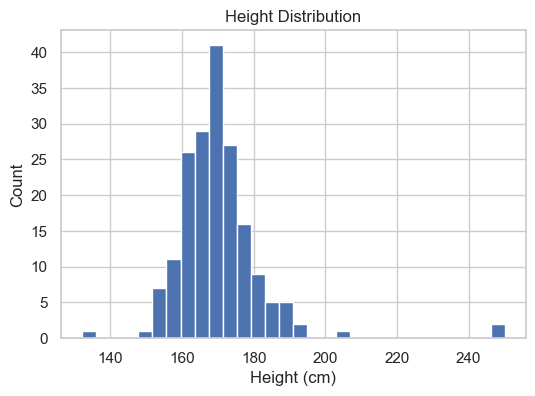

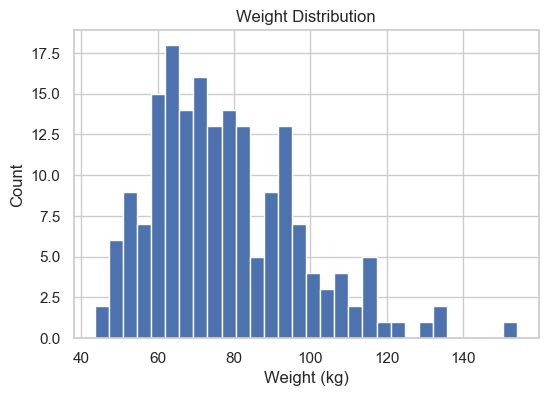

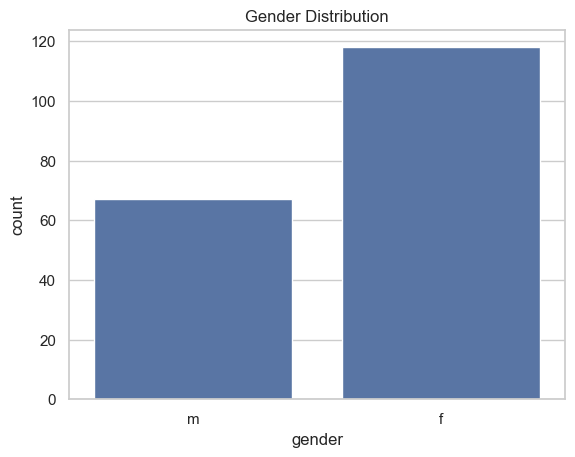

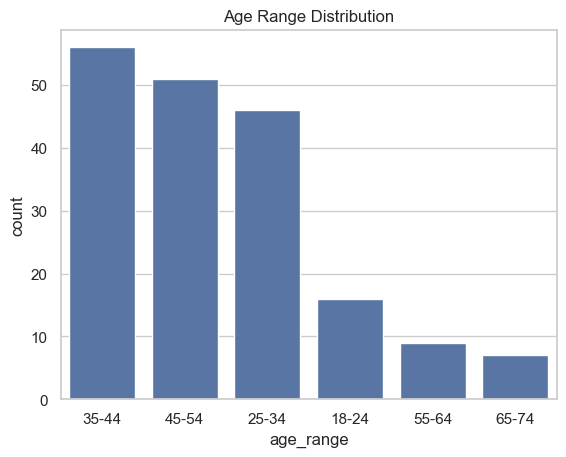

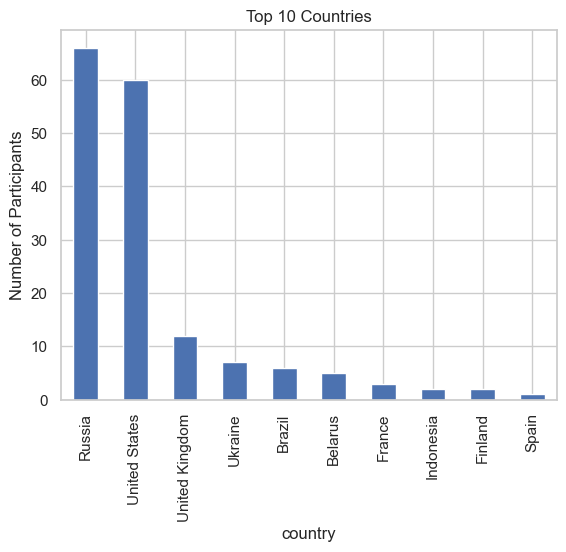

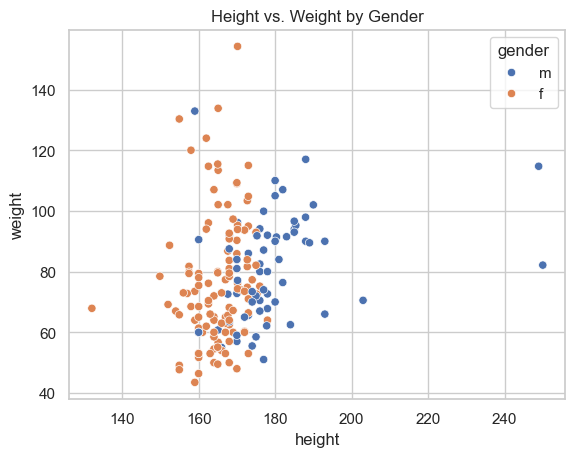

In [ ]:
# Step 6: Visual Exploration

# Histograms for height and weight
df['height'].hist(bins=30, figsize=(6,4))
plt.title("Height Distribution")
plt.xlabel("Height (cm)")
plt.ylabel("Count")
plt.show()

df['weight'].hist(bins=30, figsize=(6,4))
plt.title("Weight Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Count")
plt.show()

# Bar plots for categorical features
sns.countplot(x="gender", data=df)
plt.title("Gender Distribution")
plt.show()

sns.countplot(x="age_range", data=df, order=df['age_range'].value_counts().index)
plt.title("Age Range Distribution")
plt.show()

# Top 10 countries
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries")
plt.ylabel("Number of Participants")
plt.show()

# Scatterplot: height vs weight (colored by gender)
sns.scatterplot(x="height", y="weight", data=df, hue="gender")
plt.title("Height vs. Weight by Gender")
plt.show()

## 7. Data Cleaning 

**Question:**  
*Discuss and implement strategies for handling missing values, duplicates, and outliers. Perform transformations as needed.*

**Answer:** 
Based on the data quality checks, we will clean the dataset:

- **Duplicates**: Dropping any exact duplicate rows (same user recorded twice).  
- **Missing values**: 
  - For `height` and `weight`, filling missing values with the median (because medians are less sensitive to outliers).  
  - For `city`, we will leave missing as is, since location is not critical for this exploration.  
  - For `symptoms_onset`, missing means the participant reported no symptoms, so we will keep them as empty.  
- **Outliers**: removing unrealistic values (e.g., heights below 130 cm or above 220 cm, weights below 30 kg or above 200 kg).  
- **Data types**: Convert `symptoms_onset` into a datetime format.  

This way we are **keeping as much data as possible** while **removing clearly incorrect values**.

In [ ]:
# Step 7: Data Cleaning

# remove duplicates
df = df.drop_duplicates()

# ronvert height and weight to numeric (in case any are stored as text)
df['height'] = pd.to_numeric(df['height'], errors="coerce")
df['weight'] = pd.to_numeric(df['weight'], errors="coerce")

# handle missing values
df['height'] = df['height'].fillna(df['height'].median())
df['weight'] = df['weight'].fillna(df['weight'].median())

# handle outliers
df = df[(df['height'] >= 130) & (df['height'] <= 220)]
df = df[(df['weight'] >= 30) & (df['weight'] <= 200)]

# convert symptoms_onset to datetime
df['symptoms_onset'] = pd.to_datetime(df['symptoms_onset'], errors="coerce")

print("Cleaned dataset shape:", df.shape)
print(df.head(20))

Cleaned dataset shape: (183, 8)
     user_code gender age_range           city         country  height  \
0   007b8190cf      m     25-34       Mandalay         Myanmar  170.18   
1   013f6d3e5b      f     18-24      São Paulo          Brazil  174.00   
2   01bad5a519      m     45-54  St Petersburg          Russia  178.00   
3   0210b20eea      f     25-34          Sochi          Russia  169.00   
4   024719e7da      f     45-54  St Petersburg          Russia  158.00   
5   02a2b827c9      m     25-34            NaN          Russia  177.00   
6   02b528c2fe      f     35-44         Moscow          Russia  178.00   
7   03c83694ae      f     35-44     Burlington   United States  160.02   
8   05bcfae0a4      m     35-44        Atlanta   United States  168.00   
9   0bdfbddb2b      f     18-24       Teren'ga          Russia  159.00   
10  0d297d2410      m     35-44         Moscow          Russia  173.00   
11  0f2d7af30c      f     25-34   Bila Tserkva         Ukraine  164.00   
12  10

## 8. Feature Engineering & Visualization

**Question:**  
*Create at least one new feature and document the approach.*

**Answer:**  
To make the dataset more useful, I creates 2 new features and added their visualizations:

- **BMI (Body Mass Index)**:  
  BMI = weight (kg) / (height in meters)^2  
  It is useful because two people with the same weight but different heights can have very different health profiles.  

- **had_symptoms**:  
  A binary variable (1 if a participant reported a symptom onset date, 0 if not).  
  This makes it easier to group and compare participants who reported COVID symptoms vs. those who did not.

Both features add insight and make the dataset more ready for later analysis.

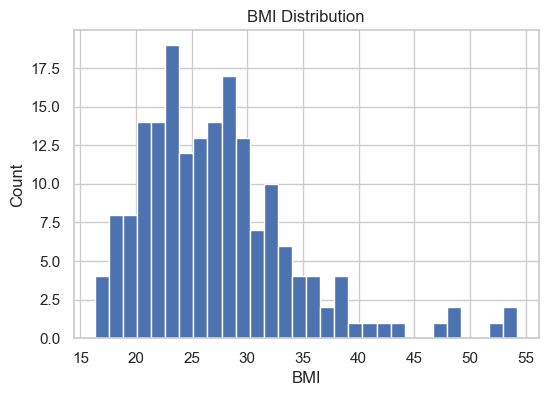

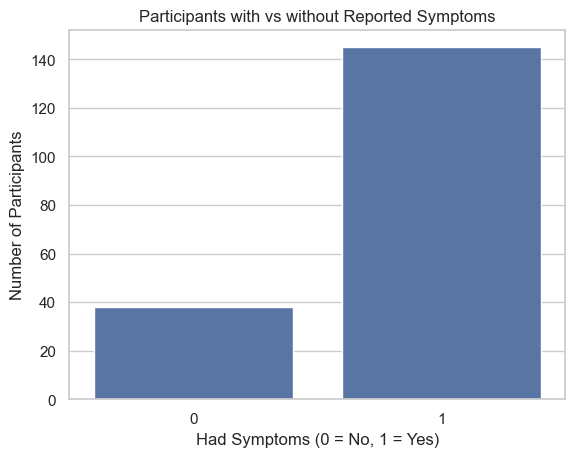

In [14]:
# Step 8: Feature Engineering

# calculate BMI
df['BMI'] = df['weight'] / (df['height']/100)**2

# create had_symptoms flag
df['had_symptoms'] = df['symptoms_onset'].notnull().astype(int)

# preview new features
df[['height', 'weight', 'BMI', 'symptoms_onset', 'had_symptoms']].head()

# visualize BMI distribution
df['BMI'].hist(bins=30, figsize=(6,4))
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()

# bar plot for had_symptoms
sns.countplot(x="had_symptoms", data=df)
plt.title("Participants with vs without Reported Symptoms")
plt.xlabel("Had Symptoms (0 = No, 1 = Yes)")
plt.ylabel("Number of Participants")
plt.show()

## 9. Data Quality Assessment

**Question:**  
*Include a discussion around data quality (profiling, completeness, accuracy, consistency, integrity, provenance).*

**Answer:**  
Here we reflect on the overall quality of the `participants.csv` dataset.

### Data Profiling
- The dataset contains information on 183 participants (after cleaning).  
- Columns include user ID, demographics (gender, age range, country), height and weight, plus symptom onset dates.  
- Data is fairly wide-ranging with participants from multiple countries.  

### Completeness
- Some columns (like `city` and `symptoms_onset`) have many missing values.  
- Height and weight are mostly complete, though a few values were missing and were imputed with the median.  

### Accuracy
- Most values seem reasonable, with few unrealistic entries (e.g., extremely tall/short participants, very high weights).  
- These were handled by removing outliers outside a realistic range.  
- Some symptom onset dates were suspicious (e.g., far outside 2020–2021), but were kept for now unchanged.   
  For now, I left them in because it’s not clear if they are typos or special cases.  
  In a real project, I would confirm with domain experts before removing them.  

### Consistency
- Gender values are consistent (“m” and “f”).  
- Age ranges follow a standard pattern (“18-24”, “25-34”, etc.).  
- Country names are mostly consistent, though there may be some variations in spelling.  

### Integrity
- Heights and weights now line up with realistic BMI values.  
- No duplicate participants remain.  
- Relationships between columns (e.g., height vs. weight) make sense after cleaning.  

### Lineage / Provenance
- Data comes from the Welltory app.  
- Participants self-reported demographics and COVID symptom onset.  
- Self-reported data may contain errors or biases (e.g., incorrect height/weight, only tech-savvy users included).  

**Overall:**  
The dataset is **messy but usable**. After cleaning, it is consistent enough for basic analysis.  
It still has limitations due to self-reporting and missing values, so results should be interpreted with caution.

## 10. Summary of Findings


**Question:**  
*Provide rationale for choices and summarize findings.*

**Answer:**  
In this exploration of the `participants.csv` dataset from the Welltory COVID-19 Open Data project, we learned the following:

### Key Insights
- The dataset contains **183 participants** after cleaning.  
- Participants are from multiple countries, with Russia and the United States among the most common.  
- Gender distribution is skewed (more females than males).  
- Age ranges are mostly concentrated in **25–44 years old**.  
- Height and weight distributions look realistic after cleaning, with most BMI values falling in the 18–35 range.  
- Around **72% of participants** reported a COVID symptom onset date.  

### Data Quality Issues and Fixes
- **Missing values**: Found in `height`, `weight`, `city`, and `symptoms_onset`. Handled with median imputation (for height/weight) and leaving blanks (for city and symptom onset).  
- **Duplicates**: Dropped duplicate rows to ensure one record per participant.  
- **Outliers**: Removed unrealistic height (<130 cm or >220 cm) and weight (<30 kg or >200 kg).  
- **Inconsistent values**: Gender and age ranges were consistent, country names were mostly clean.  

### Limitations
- Data is **self-reported**, which means some values may be inaccurate.  
- The dataset only includes Welltory app users, so it is **not representative of the general population**.  
- Many participants did not report symptom onset, so results related to COVID symptoms may be incomplete.  

**Overall:**  
The dataset is messy but usable. After cleaning, it provides a valuable starting point for exploring how participant demographics relate to COVID-19 symptom reporting.